# Lab 1.2 — Clustering Counties by Air Quality (K-Means)  *(SOLUTION / instructor copy)*

*Course 1258 — Applied AI for Government IT Professionals · Ch01 AI and ML
Foundations for Government · 30 minutes (flex — your instructor may skip
this) · CloudShare VM (JupyterLab) · pandas + scikit-learn — no API key
needed*

## Objectives

By the end of this lab, you will:

- Run K-Means on a real EPA dataset and interpret the clusters.
- Choose k deliberately rather than by default.
- Explain an unsupervised result to a non-technical stakeholder.

## Setup

- **Dataset:** `data/epa_aqi_by_county.csv` — EPA annual AQI by county,
  2024. Provenance in `data/MANIFEST.json`.
- **Tools:** pandas, scikit-learn, matplotlib — no API key needed.
- Instructor copies live in `solutions/`, one level below `labs/` — the
  first cell finds `labs/` (where `lab_common.py` and `data/` are) and runs
  from there.

In [1]:
# Instructor copies live in solutions/, one level below labs/ — find labs/
# (where lab_common.py and data/ are) and run from there.
import os, sys
from pathlib import Path

for _cand in (Path.cwd(), *Path.cwd().parents):
    if (_cand / "lab_common.py").is_file():
        os.chdir(_cand)
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break

## Steps

1. **(3 min)** Load `epa_aqi_by_county.csv`.
2. **(4 min)** Select the numeric day-count columns and scale them.
3. **(5 min)** Fit K-Means k=3; print each cluster's size and column means.
4. **(3 min)** Name each cluster in plain English.
5. **(6 min)** Sweep k from 2 to 8, plot inertia, choose a defensible k.
6. **(5 min)** List the worst-cluster counties; sanity-check raw rows.
7. **(4 min)** Two sentences a programme director could act on.

### Step 1 — Load the EPA annual summary

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

epa = pd.read_csv("data/epa_aqi_by_county.csv")
print("shape:", epa.shape, "| states/territories:", epa["State"].nunique())
print("columns:", list(epa.columns))
epa.head(3)

shape: (997, 18) | states/territories: 54
columns: ['State', 'County', 'Year', 'Days with AQI', 'Good Days', 'Moderate Days', 'Unhealthy for Sensitive Groups Days', 'Unhealthy Days', 'Very Unhealthy Days', 'Hazardous Days', 'Max AQI', '90th Percentile AQI', 'Median AQI', 'Days CO', 'Days NO2', 'Days Ozone', 'Days PM2.5', 'Days PM10']


,State,County,Year,Days with AQI,Good Days,Moderate Days,Unhealthy for Sensitive Groups Days,Unhealthy Days,Very Unhealthy Days,Hazardous Days,Max AQI,90th Percentile AQI,Median AQI,Days CO,Days NO2,Days Ozone,Days PM2.5,Days PM10
0,Alabama,Baldwin,2024,355,278,77,0,0,0,0,90,58,40,0,0,127,228,0
1,Alabama,Clay,2024,354,307,47,0,0,0,0,75,52,29,0,0,0,354,0
2,Alabama,DeKalb,2024,366,277,89,0,0,0,0,87,57,43,0,0,242,124,0


### Step 2 — Select and scale the features

**Why scaling matters (expected checkpoint answer):** `Good Days` runs
0–360; `Hazardous Days` runs 0–4. Unscaled, Euclidean distance is dominated
by whichever feature has the biggest numbers, so "a county with four
hazardous days" would look almost identical to "a county with none" as long
as their good-day counts matched. Scaling gives every feature equal weight.

In [3]:
FEATURES = ["Good Days", "Moderate Days", "Unhealthy for Sensitive Groups Days",
            "Unhealthy Days", "Very Unhealthy Days", "Hazardous Days"]

X = StandardScaler().fit_transform(epa[FEATURES])
print("scaled feature matrix:", X.shape)

scaled feature matrix: (997, 6)


### Step 3 — Fit k=3 and read the clusters

In [4]:
km3 = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)
epa["cluster_k3"] = km3.labels_

means = epa.groupby("cluster_k3")[FEATURES + ["Median AQI"]].mean().round(1)
means["counties"] = epa["cluster_k3"].value_counts()
print(means.to_string())

            Good Days  Moderate Days  Unhealthy for Sensitive Groups Days  Unhealthy Days  Very Unhealthy Days  Hazardous Days  Median AQI  counties
cluster_k3                                                                                                                                          
0               259.6           63.6                                  1.3             0.2                  0.0             0.0        36.6       842
1                40.3          184.3                                 71.3            55.7                 14.0             0.3        84.7         3
2               171.6          176.0                                 12.8             2.1                  0.2             0.1        51.4       152


### Step 4 — Name each cluster in plain English

**Expected cluster names:**
- **cluster 0 — the clean majority** (842 counties): ~260 good days,
  median AQI ≈ 37.
- **cluster 2 — the moderate middle** (152 counties): good and moderate days
  split roughly evenly, median AQI ≈ 51.
- **cluster 1 — the chronic bad-air counties** (just 3!): San Bernardino,
  Riverside, Los Angeles — ~56 unhealthy days each. K-Means isolates the
  extreme outliers; with k=3 they get a cluster to themselves.

### Step 5 — Choose k deliberately: the elbow method

**Expected:** the drops shrink steadily (4,338 → 3,375 → 2,603 → 2,038 → …)
with the biggest single improvement at k=4, which also splits the "moderate
middle" into a genuinely distinct event-driven group. We choose **k = 4**;
k = 3 is defensible too if the student prioritizes simplicity.

k=2  inertia=4,338
k=3  inertia=3,375
k=4  inertia=2,603
k=5  inertia=2,038
k=6  inertia=1,570
k=7  inertia=1,304
k=8  inertia=1,103


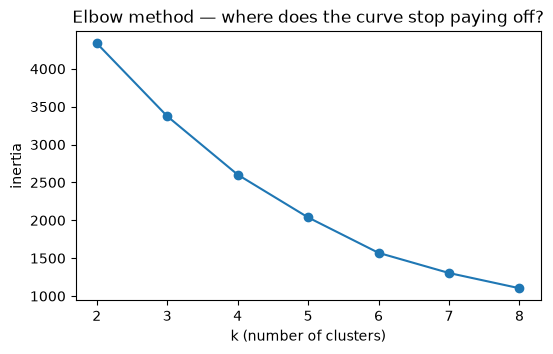

In [5]:
inertias = []
for k in range(2, 9):
    inertias.append(KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).inertia_)
for k, i in zip(range(2, 9), inertias):
    print(f"k={k}  inertia={i:,.0f}")

plt.figure(figsize=(6, 3.5))
plt.plot(range(2, 9), inertias, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("inertia")
plt.title("Elbow method — where does the curve stop paying off?")
plt.show()

### Step 6 — Fit k=4 and find the worst cluster

**Expected clusters (k=4):**
- **the clean majority** (735): ~265 good days, median AQI ≈ 36.
- **the moderate middle** (254): ~194 good / 155 moderate, median AQI ≈ 48.
- **the chronic bad-air counties** (3): San Bernardino, Riverside, Los
  Angeles — the worst cluster by far.
- **the extreme-event counties** (5): Inyo (CA), Doña Ana (NM), El Paso
  (TX) and neighbours — few unhealthy days on average but the only cluster
  with multiple *hazardous* days (wildfire smoke / dust storms).

Sanity-check: the worst-cluster rows below show day counts consistent with
the cluster means — the algorithm found the same counties a manual sort by
`Unhealthy Days` would, plus a group (extreme-event) a single-column sort
would have missed.

In [6]:
K = 4
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X)
epa["cluster"] = km.labels_
epa["unhealthy_total"] = (epa["Unhealthy Days"] + epa["Very Unhealthy Days"]
                          + epa["Hazardous Days"])

summary = epa.groupby("cluster")[FEATURES + ["Median AQI"]].mean().round(1)
summary["counties"] = epa["cluster"].value_counts()
print(summary.to_string())

worst = epa.groupby("cluster")["unhealthy_total"].mean().idxmax()
print(f"\nworst cluster: {worst}")
print(epa[epa["cluster"] == worst]
      .sort_values("unhealthy_total", ascending=False)
      [["State", "County", "unhealthy_total", "Max AQI", "Median AQI"]]
      .head(15).to_string(index=False))

         Good Days  Moderate Days  Unhealthy for Sensitive Groups Days  Unhealthy Days  Very Unhealthy Days  Hazardous Days  Median AQI  counties
cluster                                                                                                                                          
0            264.5           54.6                                  1.1             0.1                  0.0             0.0        35.5       735
1            194.4          155.0                                  8.4             1.4                  0.1             0.0        48.3       254
2             40.3          184.3                                 71.3            55.7                 14.0             0.3        84.7         3
3            178.6          159.8                                 18.6             4.6                  1.2             3.2        49.2         5

worst cluster: 2
     State         County  unhealthy_total  Max AQI  Median AQI
California San Bernardino               88

### Step 7 — Two sentences for the programme director (worked)

"America's counties fall into a clean majority (~74%), a moderate middle
(~25%), and a tiny set of outliers — three Southern California counties that
spend two months a year at unhealthy air levels, plus five counties whose
problem is rare but hazardous smoke and dust events. Start chronic-exposure
outreach in San Bernardino, Riverside and Los Angeles, and handle the
event-driven counties with emergency-communication protocols instead."

## Deliverable

1. Elbow plot; k = 4 chosen where the marginal drop flattens (k = 3
   acceptable with justification).
2. Cluster summary table with the four names above.
3. Worst-cluster county list (the three Southern California counties),
   verified against raw rows.
4. The two sentences above.

## Reflection (expected answers)

1. Higher k split the moderate middle into finer shades and isolated the
   extreme-event counties; lower k merged them back. The structure is real,
   but its *resolution* is a choice.
2. Unscaled, Good Days (range ~0–360) would dominate every distance and
   Hazardous Days (0–4) would vanish — the clusters would just be
   "many good days vs few".
3. There is no label to be correct against — that is what unsupervised
   means. The right test is whether the grouping is *useful and stable*:
   does it survive a different random seed, and does it change a decision?

## Debrief (instructor-led)

- Collect the room's cluster names from Step 4; push for names derived from
  the means, not from one famous county.
- Compare chosen k values — k=3 and k=4 are both defensible; ask a defender
  of each what they optimized for.
- Land the unsupervised punchline: no "correct" to check against — useful
  and stable is the test (does it survive a different `random_state`?).

## Troubleshooting

- **`ModuleNotFoundError: sklearn`.** Image problem — have the student run
  the Day-0 healthcheck and flag it to you.
- **Cluster numbers differ across notebooks.** Labels are arbitrary;
  compare means and county lists, not label numbers.
- **`ConvergenceWarning`.** Harmless; `n_init=10` keeps the best of ten
  fits.
- **No plot.** Re-run the cell; then Kernel → Restart & Run All.
- **Results changed after restart.** `random_state` or the feature list was
  edited — restore the provided values.